In [25]:
import pandas as pd
import numpy as np
import requests
from io import StringIO
from arch import arch_model

def get_ruonia_cbr_html(start_date, end_date):
    """
    Загрузка данных RUONIA напрямую с веб-страницы ЦБ
    Формат даты: dd.mm.yyyy
    """
    url = "https://cbr.ru/hd_base/ruonia/dynamics/"
    params = {
        "UniDbQuery.Posted": "True",
        "UniDbQuery.From": start_date,
        "UniDbQuery.To": end_date
    }
    
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
    }
    
    response = requests.get(url, params=params, headers=headers)
    
    # Читаем таблицу с веб-страницы
    # ЦБ обычно выводит данные в первой подходящей таблице
    tables = pd.read_html(StringIO(response.text))
    df = tables[0]

    # Приводим названия колонок в порядок
    print(df.columns)
    date_col = df.columns[0] # 'Дата ставки'
    rate_col = df.columns[1] #'Ставка RUONIA, % годовых'
    volume_col = df.columns[2] #'Объем сделок RUONIA, млрд руб.'
    
    df = df.rename(columns = { date_col : 'date', rate_col : 'rate', volume_col : 'volume'})

    df = df[['date', 'rate', 'volume']]
    # Преобразование типов: дата и числа с запятой
    df['date'] = pd.to_datetime(df['date'], dayfirst=True)
    if df['rate'].dtype == 'object':
        df['rate'] = df['rate'].str.replace(',', '.').astype(float)

    df['rate'] = df['rate'] / 100.0
    
    return df.sort_values('date').reset_index(drop=True)

# 1. Загрузка данных
# Укажите нужный вам диапазон
df = get_ruonia_cbr_html("01.01.2013", "11.04.2026")

# 2. Подготовка доходностей (логарифмических)
df['returns'] = np.log(df['rate'] / df['rate'].shift(1))
df = df.dropna()

# --- СПОСОБ 1: Realized Volatility по месяцам ---
# Считаем стандартное отклонение доходностей внутри месяца и аннуализируем (через корень из 252)
monthly_rv = df.groupby(df['date'].dt.to_period('M'))['returns'].agg(
    lambda x: np.std(x, ddof=1) * np.sqrt(252)
)

print("Реализованная волатильность (Monthly RV, Annualized):")
print(monthly_rv.tail())

# --- СПОСОБ 2: GARCH(1,1) ---
# Для стабильности сходимости GARCH часто масштабируют данные (* 100)
# Используем Constant Mean модель (среднее не равно 0)
garch_spec = arch_model(df['returns'] * 100, vol='Garch', p=1, q=1, dist='Normal')
res = garch_spec.fit(disp='off')

# Прогноз условной волатильности (Conditional Volatility)
df['garch_vol'] = res.conditional_volatility / 100 # масштабируем обратно

print("\nПоследние значения волатильности по GARCH(1,1):")
print(df[['date', 'rate', 'garch_vol']].tail())

# Вывод параметров модели
# alpha[1] - реакция на краткосрочные шоки
# beta[1] - инерционность волатильности
print("\nПараметры GARCH:")
print(res.params)

Index(['Дата ставки', 'Ставка RUONIA, % годовых',
       'Объем сделок RUONIA, млрд руб.', 'Количество сделок, ед.',
       'Количество участников RUONIA, совершавших сделки в данный день, ед.',
       'Минимальная процентная ставка, % годовых',
       '25-й процентиль по процентным ставкам, % годовых',
       '75-й процентиль по процентным ставкам, % годовых',
       'Максимальная процентная ставка, % годовых', 'Статус расчета',
       'Дата публикации'],
      dtype='object')
Реализованная волатильность (Monthly RV, Annualized):
date
2025-12    0.118792
2026-01    0.173004
2026-02    0.096743
2026-03    0.105673
2026-04    0.030452
Freq: M, Name: returns, dtype: float64

Последние значения волатильности по GARCH(1,1):
           date   rate  garch_vol
3250 2026-04-03  14.92   0.018944
3251 2026-04-06  14.88   0.018853
3252 2026-04-07  14.83   0.018738
3253 2026-04-08  14.83   0.018758
3254 2026-04-09  14.81   0.018760

Параметры GARCH:
mu         -0.167552
omega       2.851074
alpha[


Месячная волатильность GARCH (Annualized):
date
2025-12    0.318786
2026-01    0.340232
2026-02    0.311812
2026-03    0.313924
2026-04    0.300429
Freq: M, Name: garch_vol, dtype: float64


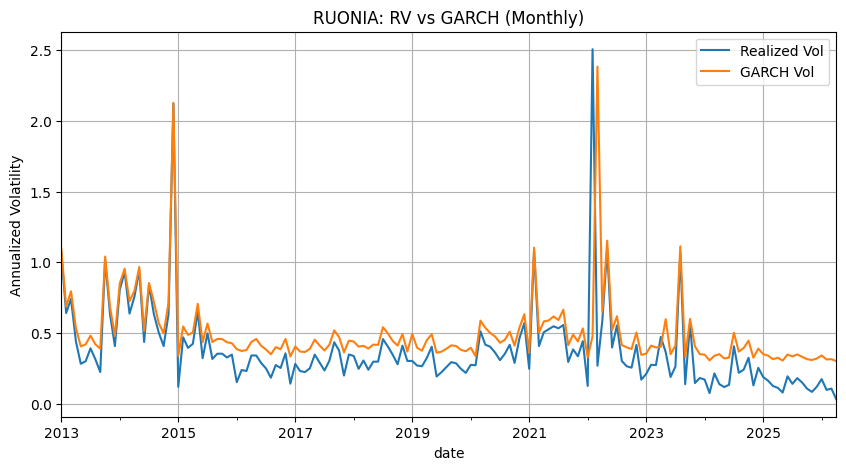

In [26]:
# --- Группировка GARCH волатильности по месяцам ---
# 1. Возводим дневную волатильность в квадрат (получаем дисперсию)
# 2. Считаем среднее за месяц
# 3. Извлекаем корень и аннуализируем
monthly_garch = df.groupby(df['date'].dt.to_period('M'))['garch_vol'].apply(
    lambda x: np.sqrt(np.mean(x**2)) * np.sqrt(252)
)

print("\nМесячная волатильность GARCH (Annualized):")
print(monthly_garch.tail())

# --- Сравнение результатов ---
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    'Realized Vol': monthly_rv,
    'GARCH Vol': monthly_garch
})

comparison.plot(figsize=(10, 5), title='RUONIA: RV vs GARCH (Monthly)')
plt.ylabel('Annualized Volatility')
plt.grid(True)
plt.show()

In [27]:
# 1. Объединяем два Series в один DataFrame
# Склеиваем по оси колонок (axis=1)
vol_comparison = pd.concat([monthly_rv, monthly_garch], axis=1)

# 2. Переименовываем колонки
vol_comparison.columns = ['Realized_Vol', 'GARCH_Vol']

# 3. Приводим индекс из типа Period ('2024-01') к Timestamp ('2024-01-01')
# Это полезно для построения графиков и слияния с другими таблицами
vol_comparison.index = vol_comparison.index.to_timestamp()

# 4. Называем индекс 'Date'
vol_comparison.index.name = 'Date'

print("Объединенный DataFrame волатильности (месячный):")
print(vol_comparison.tail())

# Теперь можно легко сохранить в CSV или Excel
# vol_comparison.to_csv('ruonia_volatility.csv')

Объединенный DataFrame волатильности (месячный):
            Realized_Vol  GARCH_Vol
Date                               
2025-12-01      0.118792   0.318786
2026-01-01      0.173004   0.340232
2026-02-01      0.096743   0.311812
2026-03-01      0.105673   0.313924
2026-04-01      0.030452   0.300429


In [28]:
vol_comparison

,Realized_Vol,GARCH_Vol
Date,,
2013-01-01,1.069126,1.096052
2013-02-01,0.640305,0.685755
2013-03-01,0.741030,0.794302
2013-04-01,0.440190,0.534814
2013-05-01,0.281309,0.404495
...,...,...
2025-12-01,0.118792,0.318786
2026-01-01,0.173004,0.340232
2026-02-01,0.096743,0.311812


In [35]:
# 1. Получаем последнее значение RUONIA за каждый месяц
monthly_rate = df.groupby(df['date'].dt.to_period('M'))['rate'].last()

# 2. Объединяем волатильности (те, что сделали раньше)
vol_comparison = pd.concat([monthly_rv, monthly_garch], axis=1)
vol_comparison.columns = ['Realized_Vol', 'GARCH_Vol']

# 3. Добавляем колонку со ставкой RUONIA
# Все три Series имеют одинаковый индекс Period, поэтому склеятся без проблем
final_df = pd.concat([monthly_rate, vol_comparison], axis=1)

# 4. Финальное оформление
final_df.index = final_df.index.to_timestamp()
final_df.index.name = 'Date'
final_df = final_df.rename(columns={'rate': 'RUONIA_end_of_month'})

print("Итоговый DataFrame (RUONIA + Volatility):")
print(final_df.tail())

Итоговый DataFrame (RUONIA + Volatility):
            RUONIA_end_of_month  Realized_Vol  GARCH_Vol
Date                                                    
2025-12-01                15.85      0.118792   0.318786
2026-01-01                15.83      0.173004   0.340232
2026-02-01                15.30      0.096743   0.311812
2026-03-01                14.87      0.105673   0.313924
2026-04-01                14.81      0.030452   0.300429


In [36]:
# 3. Конвертируем индекс в формат YYYY-MM (строковый тип)
final_df.index = final_df.index.strftime('%Y-%m')
final_df.index.name = 'Date'

In [37]:
final_df.to_csv('ruonia_rate.csv')
final_df.to_excel('ruonia_rate.xlsx')

In [2]:
!pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
